In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

import re
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

import joblib   # model save / load


In [2]:
df = pd.read_csv("sentiment.csv")   # adjust path if needed

print("Shape :", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:", df.columns.tolist())
print("\nValue counts (raw):")
print(df.iloc[:, -1].value_counts())   # assumes last col = label


Shape : (50000, 2)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Column names: ['review', 'sentiment']

Value counts (raw):
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [3]:

text_col      = [c for c in df.columns if c.lower() in ("text","tweet","review","sentence","content")][0]
sentiment_col = [c for c in df.columns if c.lower() in ("sentiment","label","polarity","target","class")][0]

df = df[[text_col, sentiment_col]].rename(columns={text_col: "text", sentiment_col: "label"})
df.dropna(inplace=True)
df["text"] = df["text"].astype(str)

# Map labels to 0 / 1 if they're strings
label_map = {}
unique_labels = df["label"].unique()
if set(str(l).lower() for l in unique_labels) & {"positive","pos","1"}:
    df["label"] = df["label"].apply(
        lambda x: 1 if str(x).lower() in ("positive","pos","1") else 0
    )
else:
    le = LabelEncoder()
    df["label"] = le.fit_transform(df["label"])

print("\nCleaned label distribution:")
print(df["label"].value_counts())




Cleaned label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


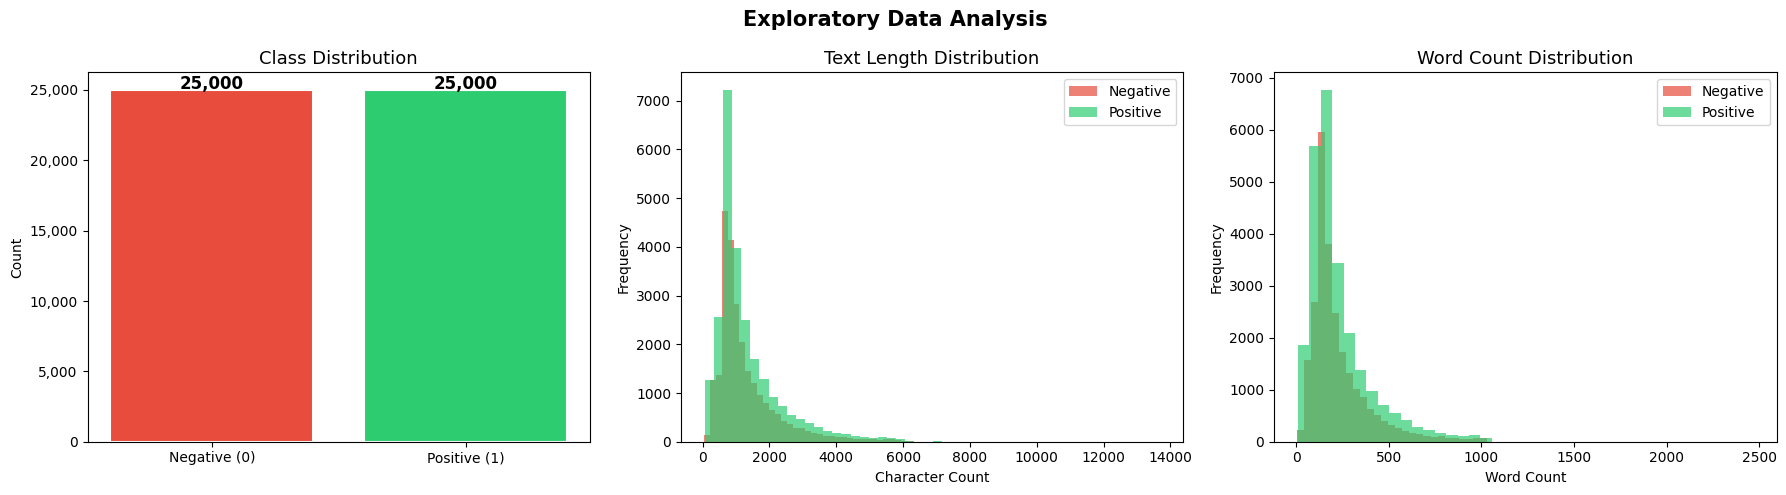

EDA chart saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=15, fontweight="bold")

# 3-a  Class distribution bar chart
counts = df["label"].value_counts().sort_index()
bars = axes[0].bar(["Negative (0)", "Positive (1)"], counts.values,
                   color=["#E74C3C", "#2ECC71"], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{int(x):,}"))
# 3-b  Review length distribution
df["length"] = df["text"].str.len()
axes[1].hist(df[df["label"]==0]["length"], bins=50, alpha=0.7, color="#E74C3C", label="Negative")
axes[1].hist(df[df["label"]==1]["length"], bins=50, alpha=0.7, color="#2ECC71", label="Positive")
axes[1].set_title("Text Length Distribution", fontsize=13)
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()
# 3-c  Word count distribution
df["word_count"] = df["text"].str.split().str.len()
axes[2].hist(df[df["label"]==0]["word_count"], bins=40, alpha=0.7, color="#E74C3C", label="Negative")
axes[2].hist(df[df["label"]==1]["word_count"], bins=40, alpha=0.7, color="#2ECC71", label="Positive")
axes[2].set_title("Word Count Distribution", fontsize=13)
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA chart saved.")

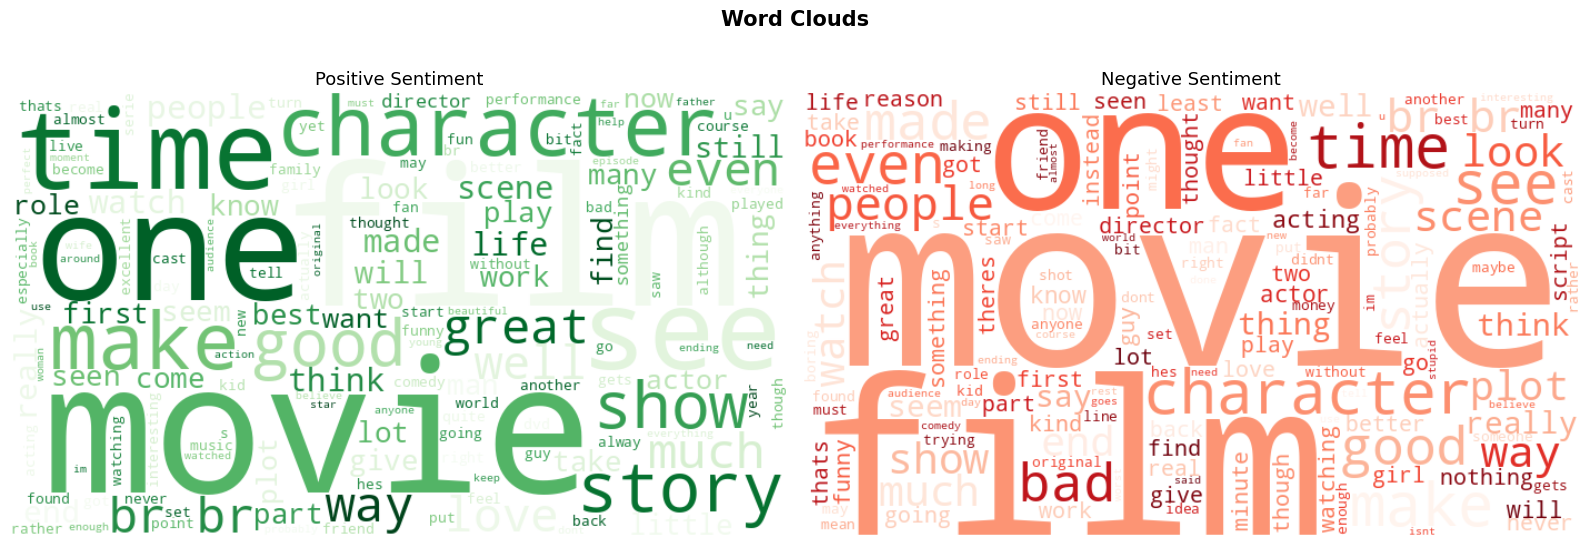

Word cloud chart saved.


In [5]:
# ── STEP 4 · Word Clouds ─────────────────────────────────────
def clean_for_wc(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

pos_text = " ".join(df[df["label"]==1]["text"].apply(clean_for_wc))
neg_text = " ".join(df[df["label"]==0]["text"].apply(clean_for_wc))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Word Clouds", fontsize=15, fontweight="bold")

wc_pos = WordCloud(width=700, height=400, background_color="white",
                   colormap="Greens", max_words=150).generate(pos_text)
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Sentiment", fontsize=13)

wc_neg = WordCloud(width=700, height=400, background_color="white",
                   colormap="Reds", max_words=150).generate(neg_text)
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative Sentiment", fontsize=13)

plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
print("Word cloud chart saved.")

In [6]:


# ── STEP 5 · Text Preprocessing ──────────────────────────────
STOPWORDS = {
    "i","me","my","myself","we","our","ours","you","your","yours","he","him",
    "his","she","her","it","its","they","them","their","what","which","who",
    "this","that","am","is","are","was","were","be","been","being","have",
    "has","had","do","does","did","but","if","or","because","as","of","at",
    "by","for","with","about","to","from","in","on","so","then","than",
    "a","an","the","and","not","no","nor","just","up","s","t","don","can",
    "will","would","should","now","d","ll","m","o","re","ve","y","ain",
    "aren","couldn","didn","doesn","hadn","hasn","haven","isn","ma","mightn",
    "mustn","needn","shan","shouldn","wasn","weren","won","wouldn"
}

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", " ", text)   # remove URLs, mentions, hashtags
    text = re.sub(r"<[^>]+>", " ", text)                      # strip HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)                     # keep letters only
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

print("Preprocessing texts …")
df["clean_text"] = df["text"].apply(preprocess)
print(" Done! Sample:")
print(df[["text","clean_text"]].head(3).to_string())

Preprocessing texts …
 Done! Sample:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [7]:
# ── STEP 6 · Train / Test Split ──────────────────────────────
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")




Train size : 40,000
Test  size : 10,000


In [8]:
# ── STEP 7 · Build & Train Pipeline ──────────────────────────
#  TF-IDF  +  Logistic Regression  →  best accuracy for text
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams
        max_features=80_000,
        sublinear_tf=True,    # log-scale TF → dampens high-freq terms
        min_df=3,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        C=5.0,
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

print("Training … (this takes ~30 s on a T4 GPU runtime)")
pipeline.fit(X_train, y_train)
print("Training complete!")



Training … (this takes ~30 s on a T4 GPU runtime)
Training complete!


In [9]:

# ── STEP 8 · Evaluation ──────────────────────────────────────
y_pred      = pipeline.predict(X_test)
y_proba     = pipeline.predict_proba(X_test)[:, 1]
test_acc    = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative","Positive"]))


  TEST ACCURACY : 91.43%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91      5000
    Positive       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [10]:
# 5-fold Cross-Validation
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"\n5-Fold CV Accuracy : {cv_scores.mean()*100:.2f}%  ±  {cv_scores.std()*100:.2f}%")



5-Fold CV Accuracy : 90.94%  ±  0.29%


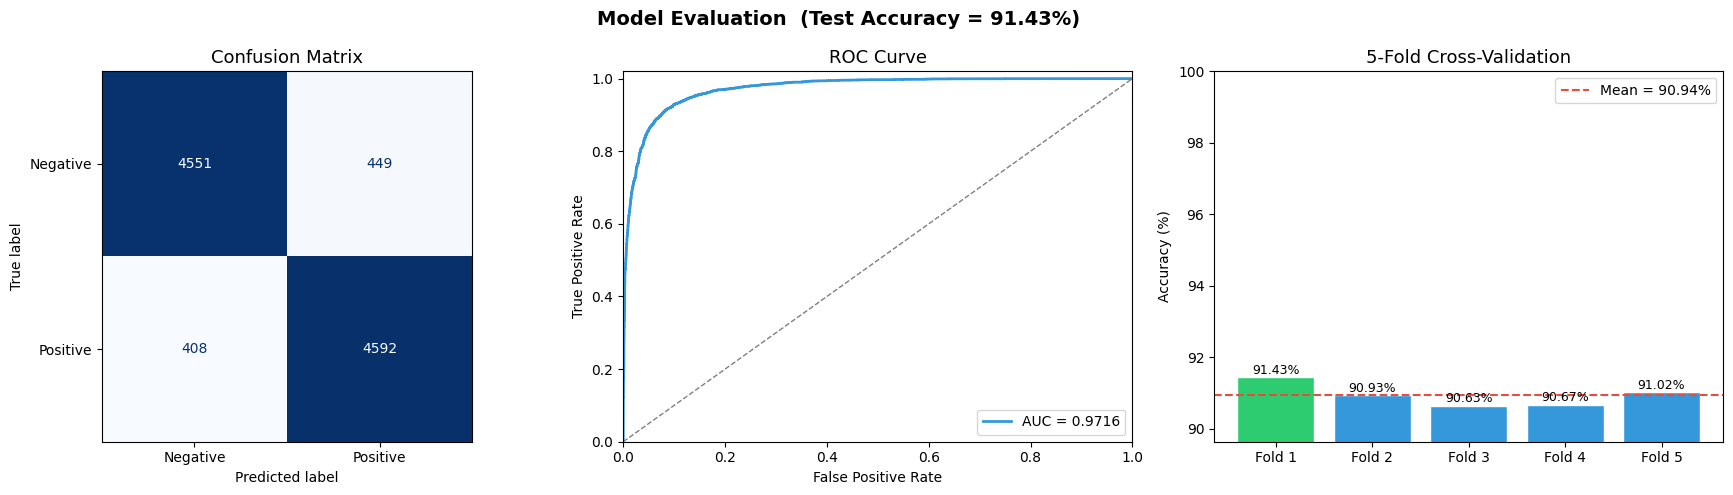

Evaluation chart saved.


In [11]:
# ── STEP 9 · Evaluation Visualisations ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Model Evaluation  (Test Accuracy = {test_acc*100:.2f}%)",
             fontsize=14, fontweight="bold")

# 9-a  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Positive"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=13)

# 9-b  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#3498DB", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0,1],[0,1],"--", color="grey", lw=1)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13)
axes[1].legend(loc="lower right")

# 9-c  Cross-Validation Accuracy
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
colors = ["#2ECC71" if s == cv_scores.max() else "#3498DB" for s in cv_scores]
bars = axes[2].bar(fold_labels, cv_scores * 100, color=colors, edgecolor="white")
axes[2].axhline(cv_scores.mean()*100, color="#E74C3C", linestyle="--", lw=1.5,
                label=f"Mean = {cv_scores.mean()*100:.2f}%")
for bar, val in zip(bars, cv_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val*100:.2f}%", ha="center", fontsize=9)
axes[2].set_ylim([min(cv_scores)*100 - 1, 100])
axes[2].set_title("5-Fold Cross-Validation", fontsize=13)
axes[2].set_ylabel("Accuracy (%)")
axes[2].legend()

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Evaluation chart saved.")



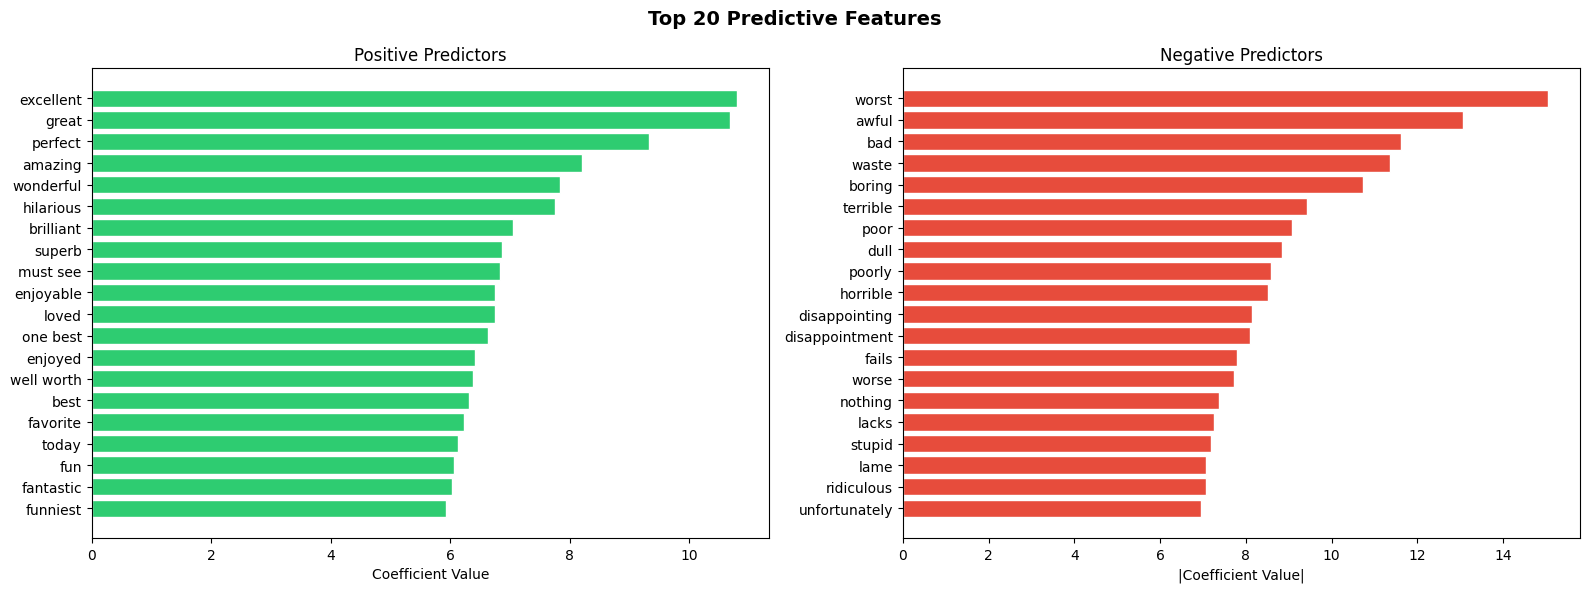

Top features chart saved.


In [12]:
# ── STEP 10 · Top Features ────────────────────────────────────
tfidf_vocab  = pipeline.named_steps["tfidf"].get_feature_names_out()
coef         = pipeline.named_steps["clf"].coef_[0]

top_n = 20
top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 20 Predictive Features", fontsize=14, fontweight="bold")

axes[0].barh(tfidf_vocab[top_pos_idx][::-1], coef[top_pos_idx][::-1],
             color="#2ECC71", edgecolor="white")
axes[0].set_title("Positive Predictors", fontsize=12)
axes[0].set_xlabel("Coefficient Value")

axes[1].barh(tfidf_vocab[top_neg_idx][::-1], np.abs(coef[top_neg_idx][::-1]),
             color="#E74C3C", edgecolor="white")
axes[1].set_title("Negative Predictors", fontsize=12)
axes[1].set_xlabel("|Coefficient Value|")

plt.tight_layout()
plt.savefig("top_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top features chart saved.")


In [13]:
# ── STEP 11 · SAVE Model ─────────────────────────────────────
MODEL_PATH = "sentiment_model.joblib"
joblib.dump(pipeline, MODEL_PATH)
print(f"\nModel saved")



Model saved


In [14]:
# ── STEP 12 · LOAD Model & Inference ─────────────────────────
loaded_model = joblib.load(MODEL_PATH)
print(f"Model loaded from {MODEL_PATH}\n")

test_sentences = [
    "I absolutely love this product, it's amazing!",
    "This is the worst experience I've ever had. Terrible!",
    "It's okay, nothing special really.",
    "Fantastic! Exceeded all my expectations.",
    "I hate how slow and buggy this is.",
]

print("=" * 55)
print(f"{'Text':<42} {'Prediction':>12}")
print("=" * 55)
for sentence in test_sentences:
    cleaned    = preprocess(sentence)
    prediction = loaded_model.predict([cleaned])[0]
    confidence = loaded_model.predict_proba([cleaned])[0][prediction]
    label      = "POSITIVE" if prediction == 1 else "NEGATIVE"
    print(f"{sentence[:40]:<42} {label}  ({confidence*100:.1f}%)")
print("=" * 55)


Model loaded from sentiment_model.joblib

Text                                         Prediction
I absolutely love this product, it's ama   POSITIVE  (98.0%)
This is the worst experience I've ever h   NEGATIVE  (99.9%)
It's okay, nothing special really.         NEGATIVE  (99.0%)
Fantastic! Exceeded all my expectations.   POSITIVE  (94.3%)
I hate how slow and buggy this is.         NEGATIVE  (76.2%)
